In [1]:
import os

# Prevent OpenMP / temporary directory issues that can crash the notebook kernel
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TMPDIR"] = "/tmp"

print("Environment configured: OMP_NUM_THREADS=1, TMPDIR=/tmp")

Environment configured: OMP_NUM_THREADS=1, TMPDIR=/tmp


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [3]:
import sys
print(sys.executable)
print(sys.version)

/Users/apple/dev/EvoFinGraph/.venv/bin/python
3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)]


In [4]:
from src.models.base import BaseModel

In [5]:
BaseModel

src.models.base.BaseModel

In [6]:
import importlib

import src.config
import src.pipeline.builder
import src.graph.converter
import src.models.graphsage

importlib.reload(src.pipeline.builder)
importlib.reload(src.graph.converter)
importlib.reload(src.models.graphsage)

from src.pipeline.builder import EvoFinGraphPipeline
from src.graph.converter import GraphConverter
from src.models.graphsage import GraphSAGEModel

In [7]:
pipeline = EvoFinGraphPipeline()

pipeline.build()

2026-07-20 14:09:35,246 | INFO | Loading processed dataset...
2026-07-20 14:09:47,567 | INFO | Dataset loaded successfully.
2026-07-20 14:09:47,569 | INFO | Building temporal graphs...
2026-07-20 14:09:47,569 | INFO | Building graph for timestep 20
2026-07-20 14:09:47,756 | INFO | Graph built successfully | Nodes: 900 | Edges: 613
2026-07-20 14:09:47,757 | INFO | Snapshot 20 validated.
2026-07-20 14:09:47,809 | INFO | Detected 327 communities.
2026-07-20 14:09:47,811 | INFO | Building graph for timestep 21
2026-07-20 14:09:47,952 | INFO | Graph built successfully | Nodes: 641 | Edges: 518
2026-07-20 14:09:47,952 | INFO | Snapshot 21 validated.
2026-07-20 14:09:47,983 | INFO | Detected 238 communities.
2026-07-20 14:09:47,985 | INFO | Building graph for timestep 22
2026-07-20 14:09:48,339 | INFO | Graph built successfully | Nodes: 1763 | Edges: 1537
2026-07-20 14:09:48,340 | INFO | Snapshot 22 validated.
2026-07-20 14:09:48,443 | INFO | Detected 536 communities.
2026-07-20 14:09:48,446 

In [8]:
pipeline.summary()

EVOFINGRAPH PIPELINE
Snapshots              : 5
Tracked Communities    : 1037
Feature Matrix Shape   : (528, 16)


In [9]:
feature_matrix = pipeline.feature_matrix

feature_matrix.head()

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community
0,6,21,11,-0.151515,0.178571,-0.043478,1.357143,0.0,4.610801,0.295710,2,0.4,0.859100,1.848485,0.931084,1
1,11,21,18,0.666667,-0.169231,0.530612,-1.000000,0.0,4.278830,0.730030,2,0.4,0.903350,2.666667,0.810845,0
2,15,21,9,0.000000,0.000000,0.000000,0.000000,0.0,9.080104,0.000000,3,0.6,0.915467,2.000000,1.000000,0
3,15,22,457,0.000000,0.000000,0.000000,0.000000,0.0,4.331653,0.000000,3,0.6,0.915467,2.000000,1.000000,0
4,18,21,87,-0.391304,0.642857,0.008117,0.000000,0.0,3.258021,0.064171,4,0.8,0.793975,1.608696,0.821699,1


In [10]:
from src.models.data import ModelData

X_train, X_test, y_train, y_test = ModelData.prepare(
    feature_matrix
)

In [11]:
"""Train logistic regression model"""
from src.models.logistic import LogisticModel

model = LogisticModel()

model.fit(
    X_train,
    y_train,
)

In [12]:
importance = model.feature_importance(
    X_train.columns
)

importance

{'fraud_growth': np.float64(1.1035315533366545),
 'density_change': np.float64(0.6986070380543582),
 'structural_stability': np.float64(-0.47786163297257883),
 'feature_drift': np.float64(-0.38054042777938185),
 'degree_change': np.float64(0.24794286441997868),
 'node_churn': np.float64(0.08202755449643861),
 'growth_rate': np.float64(0.06628974916498764),
 'variance_drift': np.float64(0.0638143691491139),
 'clustering_change': np.float64(-0.014967009727762057)}

EVALUATION FOLDER'S METRICS TESTING

In [13]:
from src.evaluation.metrics import EvaluationMetrics

predictions = model.predict(
    X_test
)

probabilities = model.predict_proba(
    X_test
)

metrics = EvaluationMetrics.compute(

    y_test,

    predictions,

    probabilities,

)

metrics

{'accuracy': 0.6698113207547169,
 'precision': 0.3877551020408163,
 'recall': 0.7916666666666666,
 'f1': 0.5205479452054794,
 'roc_auc': 0.8724593495934958}

In [14]:
from src.evaluation.report import EvaluationReport

In [15]:
report = EvaluationReport()

In [16]:
report.add(
    "Logistic Regression",
    metrics,
)

In [17]:
report.summary()

MODEL COMPARISON
                 model  accuracy  precision    recall        f1   roc_auc
0  Logistic Regression  0.669811   0.387755  0.791667  0.520548  0.872459


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.669811,0.387755,0.791667,0.520548,0.872459


XGBOOST TESTING

In [18]:
from src.models.xgboost import XGBoostModel

xgb = XGBoostModel()

xgb.fit(
    X_train,
    y_train,
)

In [19]:
"""Predict"""
xgb_predictions = xgb.predict(
    X_test
)

xgb_probabilities = xgb.predict_proba(
    X_test
)

In [20]:
from src.evaluation.metrics import EvaluationMetrics

xgb_metrics = EvaluationMetrics.compute(

    y_test,

    xgb_predictions,

    xgb_probabilities,

)

xgb_metrics

{'accuracy': 0.839622641509434,
 'precision': 0.6666666666666666,
 'recall': 0.5833333333333334,
 'f1': 0.6222222222222222,
 'roc_auc': 0.853658536585366}

In [21]:
importance = xgb.feature_importance(
    X_train.columns
)

importance

{'feature_drift': np.float32(0.237506),
 'variance_drift': np.float32(0.13049889),
 'fraud_growth': np.float32(0.12957232),
 'density_change': np.float32(0.12261081),
 'structural_stability': np.float32(0.10358988),
 'growth_rate': np.float32(0.095519386),
 'degree_change': np.float32(0.09538253),
 'node_churn': np.float32(0.08532023),
 'clustering_change': np.float32(0.0)}

In [22]:
logistic_predictions = model.predict(
    X_test
)

logistic_probabilities = model.predict_proba(
    X_test
)

In [23]:
from src.evaluation.metrics import EvaluationMetrics

logistic_metrics = EvaluationMetrics.compute(

    y_test,

    logistic_predictions,

    logistic_probabilities,

)

logistic_metrics

{'accuracy': 0.6698113207547169,
 'precision': 0.3877551020408163,
 'recall': 0.7916666666666666,
 'f1': 0.5205479452054794,
 'roc_auc': 0.8724593495934958}

In [24]:
from src.evaluation.report import EvaluationReport

report = EvaluationReport()

report.add(

    "Logistic Regression",

    logistic_metrics,

)

report.add(

    "XGBoost",

    xgb_metrics,

)

comparison = report.summary()

comparison

MODEL COMPARISON
                 model  accuracy  precision    recall        f1   roc_auc
1              XGBoost  0.839623   0.666667  0.583333  0.622222  0.853659
0  Logistic Regression  0.669811   0.387755  0.791667  0.520548  0.872459


,model,accuracy,precision,recall,f1,roc_auc
1,XGBoost,0.839623,0.666667,0.583333,0.622222,0.853659
0,Logistic Regression,0.669811,0.387755,0.791667,0.520548,0.872459


In [25]:
report.rank("f1")

,model,accuracy,precision,recall,f1,roc_auc
1,XGBoost,0.839623,0.666667,0.583333,0.622222,0.853659
0,Logistic Regression,0.669811,0.387755,0.791667,0.520548,0.872459


In [26]:
import pandas as pd

comparison = pd.DataFrame({

    "Logistic": model.feature_importance(
        X_train.columns
    ),

    "XGBoost": xgb.feature_importance(
        X_train.columns
    ),

})

comparison

,Logistic,XGBoost
fraud_growth,1.103532,0.129572
density_change,0.698607,0.122611
structural_stability,-0.477862,0.103590
feature_drift,-0.380540,0.237506
degree_change,0.247943,0.095383
node_churn,0.082028,0.085320
growth_rate,0.066290,0.095519
variance_drift,0.063814,0.130499
clustering_change,-0.014967,0.000000


In [27]:
"""testing graph converter to implement graphsage"""
from src.graph.converter import GraphConverter

graph = pipeline.get_graph(20)

data = GraphConverter.to_pyg(graph)

data

/Users/apple/dev/EvoFinGraph/src/graph/converter.py:115: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  x = torch.tensor(


Data(
  x=[900, 165],
  edge_index=[2, 1226],
  y=[900],
  community=[900],
  node_mapping={
    209556175.0=0,
    52934000.0=1,
    37574467.0=2,
    209972191.0=3,
    73339227.0=4,
    209837677.0=5,
    5286455.0=6,
    209826974.0=7,
    210644361.0=8,
    25642291.0=9,
    209952987.0=10,
    209952974.0=11,
    211086336.0=12,
    209724105.0=13,
    209045031.0=14,
    210640906.0=15,
    209681259.0=16,
    209118488.0=17,
    209794811.0=18,
    209487402.0=19,
    209678521.0=20,
    209533787.0=21,
    209918381.0=22,
    209537331.0=23,
    209905828.0=24,
    210192146.0=25,
    1275118.0=26,
    4659656.0=27,
    209091416.0=28,
    209692891.0=29,
    107697436.0=30,
    209518228.0=31,
    211078002.0=32,
    209688652.0=33,
    209921231.0=34,
    209824867.0=35,
    209673949.0=36,
    209842048.0=37,
    8182823.0=38,
    209798865.0=39,
    1552384.0=40,
    209818962.0=41,
    209045727.0=42,
    209674270.0=43,
    209892725.0=44,
    58114564.0=45,
    20892789

In [28]:
print(data.community.shape)

print(data.timestep)

print(len(data.node_mapping))

print(data.reverse_mapping[0])

torch.Size([900])
20
900
209556175.0


In [29]:
import importlib
import src.graph.converter

importlib.reload(src.graph.converter)

<module 'src.graph.converter' from '/Users/apple/dev/EvoFinGraph/src/graph/converter.py'>

In [30]:
from src.graph.converter import GraphConverter

graph = pipeline.get_graph(20)

data = GraphConverter.to_pyg(graph)

print(data.num_communities)

327


In [31]:
from src.graph.converter import GraphConverter

pyg_graphs = GraphConverter.convert_all(
    pipeline.graphs
)

In [32]:
pyg_graphs.keys()

dict_keys([20, 21, 22, 23, 24])

In [33]:
pyg_graphs[20]

Data(
  x=[900, 165],
  edge_index=[2, 1226],
  y=[900],
  community=[900],
  node_mapping={
    209556175.0=0,
    52934000.0=1,
    37574467.0=2,
    209972191.0=3,
    73339227.0=4,
    209837677.0=5,
    5286455.0=6,
    209826974.0=7,
    210644361.0=8,
    25642291.0=9,
    209952987.0=10,
    209952974.0=11,
    211086336.0=12,
    209724105.0=13,
    209045031.0=14,
    210640906.0=15,
    209681259.0=16,
    209118488.0=17,
    209794811.0=18,
    209487402.0=19,
    209678521.0=20,
    209533787.0=21,
    209918381.0=22,
    209537331.0=23,
    209905828.0=24,
    210192146.0=25,
    1275118.0=26,
    4659656.0=27,
    209091416.0=28,
    209692891.0=29,
    107697436.0=30,
    209518228.0=31,
    211078002.0=32,
    209688652.0=33,
    209921231.0=34,
    209824867.0=35,
    209673949.0=36,
    209842048.0=37,
    8182823.0=38,
    209798865.0=39,
    1552384.0=40,
    209818962.0=41,
    209045727.0=42,
    209674270.0=43,
    209892725.0=44,
    58114564.0=45,
    20892789

In [34]:
print(pyg_graphs[20].timestep)

print(pyg_graphs[20].num_communities)

print(len(pyg_graphs[20].node_mapping))

20
327
900


GRAPHSAGE TESTING

In [35]:
import importlib
import src.models.graphsage

importlib.reload(src.models.graphsage)

<module 'src.models.graphsage' from '/Users/apple/dev/EvoFinGraph/src/models/graphsage.py'>

In [36]:
from src.graph.converter import GraphConverter

pyg_graphs = GraphConverter.convert_all(
    pipeline.graphs
)

graphs = list(
    pyg_graphs.values()
)

In [37]:
graphs[0]

Data(
  x=[900, 165],
  edge_index=[2, 1226],
  y=[900],
  community=[900],
  node_mapping={
    209556175.0=0,
    52934000.0=1,
    37574467.0=2,
    209972191.0=3,
    73339227.0=4,
    209837677.0=5,
    5286455.0=6,
    209826974.0=7,
    210644361.0=8,
    25642291.0=9,
    209952987.0=10,
    209952974.0=11,
    211086336.0=12,
    209724105.0=13,
    209045031.0=14,
    210640906.0=15,
    209681259.0=16,
    209118488.0=17,
    209794811.0=18,
    209487402.0=19,
    209678521.0=20,
    209533787.0=21,
    209918381.0=22,
    209537331.0=23,
    209905828.0=24,
    210192146.0=25,
    1275118.0=26,
    4659656.0=27,
    209091416.0=28,
    209692891.0=29,
    107697436.0=30,
    209518228.0=31,
    211078002.0=32,
    209688652.0=33,
    209921231.0=34,
    209824867.0=35,
    209673949.0=36,
    209842048.0=37,
    8182823.0=38,
    209798865.0=39,
    1552384.0=40,
    209818962.0=41,
    209045727.0=42,
    209674270.0=43,
    209892725.0=44,
    58114564.0=45,
    20892789

In [38]:
from importlib import reload
import src.models.graphsage

reload(src.models.graphsage)

from src.models.graphsage import GraphSAGEModel

In [39]:
from src.graph.converter import GraphConverter

pyg_graphs = GraphConverter.convert_all(
    pipeline.graphs
)

graphs = list(
    pyg_graphs.values()
)

In [40]:
sage = GraphSAGEModel(

    input_dim=graphs[0].num_node_features,

)

In [41]:
import time
from types import MethodType

def debug_fit(self, graphs, epochs=5, verbose=True):

    if not isinstance(graphs, (list, tuple)):
        graphs = [graphs]

    self.model.train()

    history = []

    total_graphs = len(graphs)

    overall_start = time.time()

    print("=" * 60)
    print(f"Training on {total_graphs} graph(s)")
    print(f"Epochs: {epochs}")
    print("=" * 60)

    for epoch in range(epochs):

        epoch_start = time.time()

        epoch_loss = 0.0

        print(f"\nEpoch {epoch+1}/{epochs}")

        for graph_idx, data in enumerate(graphs):

            graph_start = time.time()

            self.optimizer.zero_grad()

            logits = self.forward(data)

            loss = self.loss_fn(
                logits,
                data.y,
            )

            loss.backward()

            self.optimizer.step()

            epoch_loss += loss.item()

            print(
                f"  Graph {graph_idx+1}/{total_graphs} | "
                f"Nodes={data.num_nodes:,} | "
                f"Edges={data.edge_index.shape[1]:,} | "
                f"Loss={loss.item():.4f} | "
                f"{time.time()-graph_start:.2f}s"
            )

        epoch_loss /= total_graphs

        history.append(epoch_loss)

        print(
            f"Epoch finished in "
            f"{time.time()-epoch_start:.2f}s | "
            f"Average Loss={epoch_loss:.4f}"
        )

    print("\nTraining Complete!")
    print(f"Total Time: {time.time()-overall_start:.2f}s")

    return history

# Replace only this instance's fit method
sage.fit = MethodType(debug_fit, sage)

In [42]:
%whos

Variable                 Type                   Data/Info
---------------------------------------------------------
BaseModel                ABCMeta                <class 'src.models.base.BaseModel'>
EvaluationMetrics        type                   <class 'src.evaluation.me<...>trics.EvaluationMetrics'>
EvaluationReport         type                   <class 'src.evaluation.report.EvaluationReport'>
EvoFinGraphPipeline      type                   <class 'src.pipeline.buil<...>der.EvoFinGraphPipeline'>
GraphConverter           type                   <class 'src.graph.converter.GraphConverter'>
GraphSAGEModel           ABCMeta                <class 'src.models.graphsage.GraphSAGEModel'>
LogisticModel            ABCMeta                <class 'src.models.logistic.LogisticModel'>
MethodType               type                   <class 'method'>
ModelData                type                   <class 'src.models.data.ModelData'>
PROJECT_ROOT             PosixPath              /Users/apple/dev/Ev

In [43]:
print(len(graphs))

5


In [44]:
for i, graph in enumerate(graphs):

    print(
        i,
        graph.num_nodes,
        graph.edge_index.shape[1],
    )

0 900 1226
1 641 1036
2 1763 3074
3 1187 2092
4 1126 1922


In [45]:
sage = GraphSAGEModel(

    input_dim=graphs[0].num_node_features,

    hidden_dim=32,   # much faster for now

)

In [46]:
history = sage.fit(
    graphs[-3:],
    epochs=5,
)

Epoch 001 | Loss: 0.5795
Epoch 002 | Loss: 0.4091
Epoch 003 | Loss: 0.3391
Epoch 004 | Loss: 0.2951
Epoch 005 | Loss: 0.2706


In [47]:
predictions = sage.predict(
    graphs[-1]
)

probabilities = sage.predict_proba(
    graphs[-1]
)

In [48]:
from src.evaluation.metrics import EvaluationMetrics

graphsage_metrics = EvaluationMetrics.compute(

    graphs[-1].y.numpy(),

    predictions,

    probabilities[:, 1],

)

graphsage_metrics

{'accuracy': 0.8365896980461812,
 'precision': 0.20987654320987653,
 'recall': 0.12408759124087591,
 'f1': 0.1559633027522936,
 'roc_auc': 0.8016207479353177}

SAGE EVALUATION

In [49]:
predictions = sage.predict(
    graphs[-1]
)

probabilities = sage.predict_proba(
    graphs[-1]
)

In [50]:
from src.evaluation.metrics import EvaluationMetrics

graphsage_metrics = EvaluationMetrics.compute(

    graphs[-1].y.numpy(),

    predictions,

    probabilities[:, 1],

)

graphsage_metrics

{'accuracy': 0.8365896980461812,
 'precision': 0.20987654320987653,
 'recall': 0.12408759124087591,
 'f1': 0.1559633027522936,
 'roc_auc': 0.8016207479353177}

In [51]:
embeddings = sage.embeddings(
    graphs[-1]
)

embeddings.shape

(1126, 32)

# =============================================================================
# Phase 2: Results & Analysis
# =============================================================================

In [53]:
print(metrics)

{'accuracy': 0.6698113207547169, 'precision': 0.3877551020408163, 'recall': 0.7916666666666666, 'f1': 0.5205479452054794, 'roc_auc': 0.8724593495934958}


In [54]:
print(xgb_metrics)

{'accuracy': 0.839622641509434, 'precision': 0.6666666666666666, 'recall': 0.5833333333333334, 'f1': 0.6222222222222222, 'roc_auc': 0.853658536585366}


In [55]:
print(graphsage_metrics)

{'accuracy': 0.8365896980461812, 'precision': 0.20987654320987653, 'recall': 0.12408759124087591, 'f1': 0.1559633027522936, 'roc_auc': 0.8016207479353177}


In [56]:
print(metrics.keys())
print(xgb_metrics.keys())
print(graphsage_metrics.keys())

dict_keys(['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
dict_keys(['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
dict_keys(['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])


In [57]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1 Score": metrics["f1"],
        "ROC-AUC": metrics["roc_auc"],
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_metrics["accuracy"],
        "Precision": xgb_metrics["precision"],
        "Recall": xgb_metrics["recall"],
        "F1 Score": xgb_metrics["f1"],
        "ROC-AUC": xgb_metrics["roc_auc"],
    },
    {
        "Model": "GraphSAGE",
        "Accuracy": graphsage_metrics["accuracy"],
        "Precision": graphsage_metrics["precision"],
        "Recall": graphsage_metrics["recall"],
        "F1 Score": graphsage_metrics["f1"],
        "ROC-AUC": graphsage_metrics["roc_auc"],
    }
])

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6698,0.3878,0.7917,0.5205,0.8725
1,XGBoost,0.8396,0.6667,0.5833,0.6222,0.8537
2,GraphSAGE,0.8366,0.2099,0.1241,0.1560,0.8016


In [58]:
def metric_row(name, metric_dict):
    return {
        "Model": name,
        "Accuracy": metric_dict["accuracy"],
        "Precision": metric_dict["precision"],
        "Recall": metric_dict["recall"],
        "F1 Score": metric_dict["f1"],
        "ROC-AUC": metric_dict["roc_auc"],
    }

comparison = pd.DataFrame([
    metric_row("Logistic Regression", metrics),
    metric_row("XGBoost", xgb_metrics),
    metric_row("GraphSAGE", graphsage_metrics),
]).round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6698,0.3878,0.7917,0.5205,0.8725
1,XGBoost,0.8396,0.6667,0.5833,0.6222,0.8537
2,GraphSAGE,0.8366,0.2099,0.1241,0.1560,0.8016


In [59]:
from pathlib import Path

output_dir = Path("../outputs/results")
output_dir.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    output_dir / "model_comparison.csv",
    index=False,
)

print("Comparison table saved!")

Comparison table saved!


In [60]:
%whos

Variable                 Type                   Data/Info
---------------------------------------------------------
BaseModel                ABCMeta                <class 'src.models.base.BaseModel'>
EvaluationMetrics        type                   <class 'src.evaluation.me<...>trics.EvaluationMetrics'>
EvaluationReport         type                   <class 'src.evaluation.report.EvaluationReport'>
EvoFinGraphPipeline      type                   <class 'src.pipeline.buil<...>der.EvoFinGraphPipeline'>
GraphConverter           type                   <class 'src.graph.converter.GraphConverter'>
GraphSAGEModel           ABCMeta                <class 'src.models.graphsage.GraphSAGEModel'>
LogisticModel            ABCMeta                <class 'src.models.logistic.LogisticModel'>
MethodType               type                   <class 'method'>
ModelData                type                   <class 'src.models.data.ModelData'>
PROJECT_ROOT             PosixPath              /Users/apple/dev/Ev

In [61]:
from pathlib import Path
import json

metric_dir = Path("../outputs/metrics")
metric_dir.mkdir(parents=True, exist_ok=True)

metric_dict = {
    "logistic": metrics,
    "xgboost": xgb_metrics,
    "graphsage": graphsage_metrics,
}

for name, metric in metric_dict.items():
    with open(metric_dir / f"{name}.json", "w") as f:
        json.dump(metric, f, indent=4)

print("✓ Metrics saved")

✓ Metrics saved


In [62]:
results_dir = Path("../outputs/results")
results_dir.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    results_dir / "model_comparison.csv",
    index=False,
)

print("✓ Comparison table saved")

✓ Comparison table saved


In [63]:
embedding_dir = Path("../outputs/embeddings")
embedding_dir.mkdir(parents=True, exist_ok=True)

import numpy as np

np.save(
    embedding_dir / "graphsage_embeddings.npy",
    embeddings,
)

print("✓ GraphSAGE embeddings saved")

✓ GraphSAGE embeddings saved


In [64]:
print(history)

{'loss_history': [0.5794944365819296, 0.4090803563594818, 0.339054803053538, 0.2951141695181529, 0.27057663599650067], 'epochs': 5, 'final_loss': 0.27057663599650067}


In [66]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'os', '_i2', 'sys', 'Path', 'PROJECT_ROOT', '_i3', '_i4', 'BaseModel', '_i5', '_5', '_i6', 'importlib', 'src', 'EvoFinGraphPipeline', 'GraphConverter', 'GraphSAGEModel', '_i7', 'pipeline', '_7', '_i8', '_i9', 'feature_matrix', '_9', '_i10', 'ModelData', 'X_train', 'X_test', 'y_train', 'y_test', '_i11', 'LogisticModel', 'model', '_i12', 'importance', '_12', '_i13', 'EvaluationMetrics', 'predictions', 'probabilities', 'metrics', '_13', '_i14', 'EvaluationReport', '_i15', 'report', '_i16', '_i17', '_17', '_i18', 'XGBoostModel', 'xgb', '_i19', 'xgb_predictions', 'xgb_probabilities', '_i20', 'xgb_metrics', '_20', '_i21', '_21', '_i22', 'logistic_predictions', 'logistic_probabilities', '_i23', 'logistic_metrics', '_23', '_i24', 'comparison', '_24', 

In [67]:
print(type(xgb))

print(vars(xgb))

<class 'src.models.xgboost.XGBoostModel'>
{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)}


In [68]:
dir(xgb)

['__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 'feature_importance',
 'fit',
 'load',
 'model',
 'predict',
 'predict_proba',
 'save']

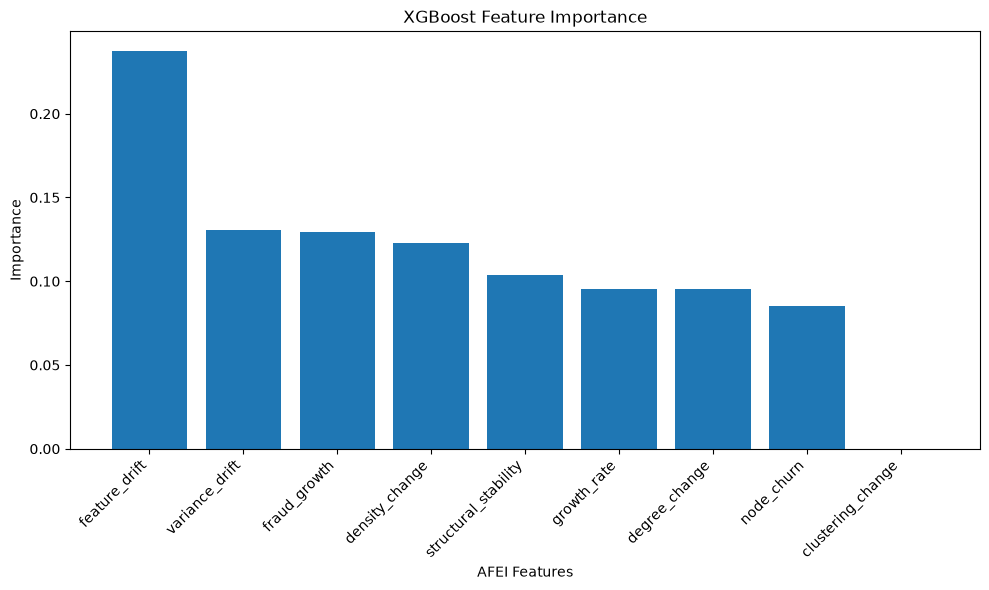

In [69]:
import matplotlib.pyplot as plt
import numpy as np

importance = xgb.model.feature_importances_

feature_names = X_train.columns

indices = np.argsort(importance)[::-1]

plt.figure(figsize=(10,6))

plt.bar(
    range(len(feature_names)),
    importance[indices]
)

plt.xticks(
    range(len(feature_names)),
    feature_names[indices],
    rotation=45,
    ha="right"
)

plt.xlabel("AFEI Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.savefig(
    "../outputs/results/xgboost_feature_importance.png",
    dpi=300,
)

plt.show()

In [70]:
importance_df = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importance
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
5,feature_drift,0.237506
6,variance_drift,0.130499
3,fraud_growth,0.129572
1,density_change,0.122611
8,structural_stability,0.103590
0,growth_rate,0.095519
2,degree_change,0.095383
7,node_churn,0.085320
4,clustering_change,0.000000


In [71]:
importance_df.to_csv(
    "../outputs/results/xgboost_feature_importance.csv",
    index=False,
)

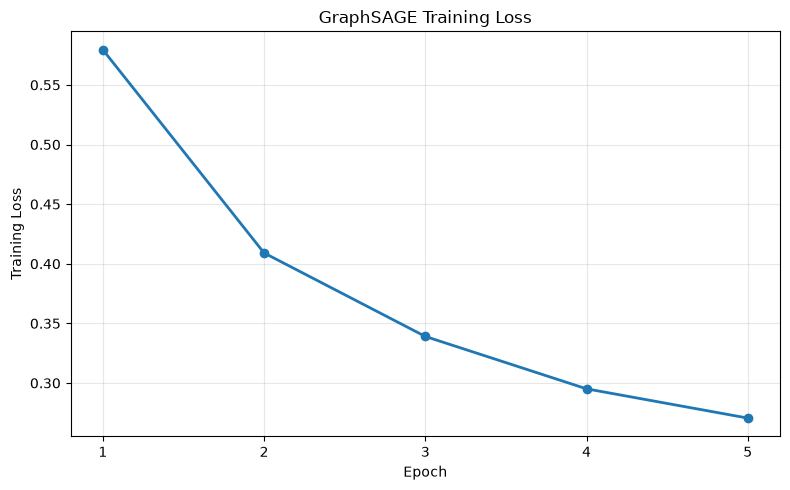

In [72]:
import matplotlib.pyplot as plt

loss = history["loss_history"]
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    loss,
    marker="o",
    linewidth=2,
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("GraphSAGE Training Loss")

plt.xticks(epochs)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/results/graphsage_training_loss.png",
    dpi=300,
)

plt.show()

In [73]:
loss_df = pd.DataFrame({
    "Epoch": epochs,
    "Loss": loss
})

loss_df.to_csv(
    "../outputs/results/graphsage_training_loss.csv",
    index=False,
)

loss_df

,Epoch,Loss
0,1,0.579494
1,2,0.409080
2,3,0.339055
3,4,0.295114
4,5,0.270577


In [74]:
print("=" * 60)
print("GraphSAGE Training Summary")
print("=" * 60)

print(f"Epochs        : {history['epochs']}")
print(f"Initial Loss  : {loss[0]:.4f}")
print(f"Final Loss    : {history['final_loss']:.4f}")
print(f"Loss Reduction: {(loss[0]-loss[-1]):.4f}")
print(f"Reduction (%) : {((loss[0]-loss[-1])/loss[0])*100:.2f}%")

GraphSAGE Training Summary
Epochs        : 5
Initial Loss  : 0.5795
Final Loss    : 0.2706
Loss Reduction: 0.3089
Reduction (%) : 53.31%


In [76]:
graphsage_probabilities = sage.predict_proba(graphs[-1])

In [78]:
print(graphsage_metrics)

{'accuracy': 0.8365896980461812, 'precision': 0.20987654320987653, 'recall': 0.12408759124087591, 'f1': 0.1559633027522936, 'roc_auc': 0.8016207479353177}


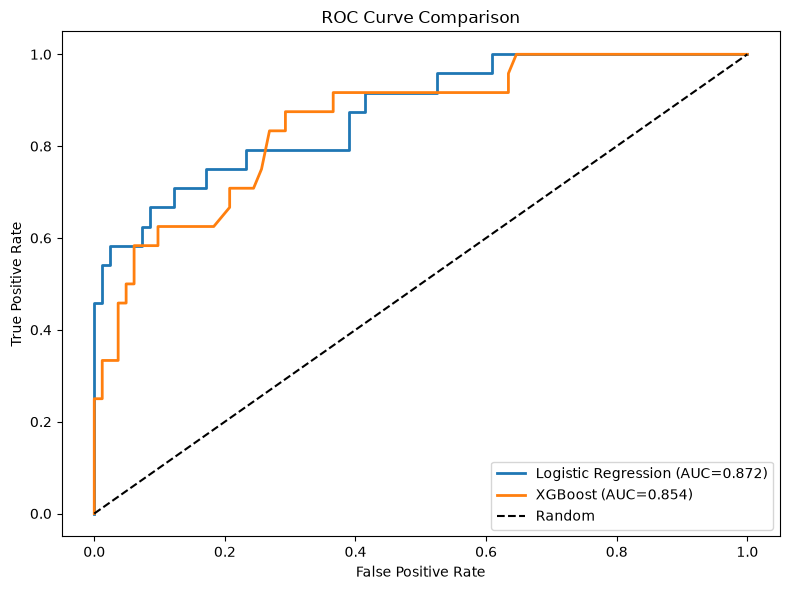

In [80]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, logistic_probabilities)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC={logistic_metrics['roc_auc']:.3f})"
)

# XGBoost
fpr, tpr, _ = roc_curve(y_test, xgb_probabilities)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost (AUC={xgb_metrics['roc_auc']:.3f})"
)

plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/results/roc_comparison.png",
    dpi=300
)

plt.show()

In [82]:
%whos

Variable                  Type                   Data/Info
----------------------------------------------------------
BaseModel                 ABCMeta                <class 'src.models.base.BaseModel'>
EvaluationMetrics         type                   <class 'src.evaluation.me<...>trics.EvaluationMetrics'>
EvaluationReport          type                   <class 'src.evaluation.report.EvaluationReport'>
EvoFinGraphPipeline       type                   <class 'src.pipeline.buil<...>der.EvoFinGraphPipeline'>
GraphConverter            type                   <class 'src.graph.converter.GraphConverter'>
GraphSAGEModel            ABCMeta                <class 'src.models.graphsage.GraphSAGEModel'>
LogisticModel             ABCMeta                <class 'src.models.logistic.LogisticModel'>
MethodType                type                   <class 'method'>
ModelData                 type                   <class 'src.models.data.ModelData'>
PROJECT_ROOT              PosixPath              /Users/